## EDA Overview

This notebook is the first step of the exploratory data analysis stage.

The analysis focuses on a general overview and validation of the training dataset before the detailed analysis of numerical and categorical features.

### Business goal

The goal of the project is to identify active customers with a high risk of churn so that the company can target them with retention actions.

The purpose of this notebook is to understand the structure and quality of the training data, verify the target distribution, and identify potential issues that may affect further analysis and data preprocessing.

### Tasks

- Load the training dataset
- Perform a basic dataset overview:
  - Display the first five rows
  - Check the dataset shape
  - Review data types
  - Count unique values
- Check duplicate and missing values
- Identify columns that should not be used as model features
- Check for potential data leakage
- Analyze the target distribution and class balance
- Summarize the main findings


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from telco_churn.config import (
    BINARY_COLUMN,
    CATEGORICAL_COLUMNS,
    ID_COLUMN,
    NUMERICAL_COLUMNS,
    TARGET_COLUMN, 
)
from telco_churn.paths import (
    EDA_OVERVIEW_DIR,
    TELCO_CUSTOMERS_TRAIN_PATH,
)
from telco_churn.plots import (
    add_bar_labels,
    save_plot,
)
from telco_churn.toolkit_functions import (
    handle_duplicates,
    report_nan,
)

## Load the training dataset: `telco_customers_train`

In [2]:
df_train = pd.read_csv(TELCO_CUSTOMERS_TRAIN_PATH)

## Basic dataset overview

In [4]:
df_train.head(3)

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,2926-JEJJC,Female,0,No,No,8,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Bank transfer (automatic),20.20,140.95,No
1,6029-CSMJE,Male,0,No,No,17,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,25.65,440.20,No
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No


In [5]:
print(
    f'Number of rows: {df_train.shape[0]}\n'
    f'Number of columns: {df_train.shape[1]}'
)

Number of rows: 5634
Number of columns: 21


In [6]:
dtypes = df_train.dtypes.rename('data_type')
nr_unique = df_train.nunique().rename('nr_of_unique_values')

dtypes_and_nr_unique = pd.concat(
    [dtypes, nr_unique],
    axis=1,
)
dtypes_and_nr_unique.index.name = 'column_name'

dtypes_and_nr_unique

,data_type,nr_of_unique_values
column_name,,
customer_id,object,5634
gender,object,2
senior_citizen,int64,2
partner,object,2
dependents,object,2
tenure,int64,73
phone_service,object,2
multiple_lines,object,3
internet_service,object,3


## Duplicate and missing values report

In [7]:
duplicates_report = handle_duplicates(
    df=df_train,
    action='report',
)

duplicates_report

{'subset_used': ['customer_id',
  'gender',
  'senior_citizen',
  'partner',
  'dependents',
  'tenure',
  'phone_service',
  'multiple_lines',
  'internet_service',
  'online_security',
  'online_backup',
  'device_protection',
  'tech_support',
  'streaming_tv',
  'streaming_movies',
  'contract',
  'paperless_billing',
  'payment_method',
  'monthly_charges',
  'total_charges',
  'churn'],
 'total_num': np.int64(0),
 'total_pct': 0.0}

In [8]:
missing_values_report = report_nan(
    df=df_train,
    target=TARGET_COLUMN,
)

missing_values_report

{'total_nan': np.int64(0),
 'columns_with_nan': [],
 'target': {'column_name': 'churn',
  'nan_total': np.int64(0),
  'nan_pct': np.float64(0.0)}}

## Target column overview: `churn`

In [9]:
churn_count = (
    df_train[TARGET_COLUMN].value_counts()
    .rename('value_counts')
)

churn_distribution = (
    (churn_count / churn_count.sum() * 100)
    .round(2)
    .rename('percentage')
)

churn_overview = pd.concat(
    [churn_count, churn_distribution],
    axis=1,
)

churn_overview

,value_counts,percentage
churn,,
No,4139,73.46
Yes,1495,26.54


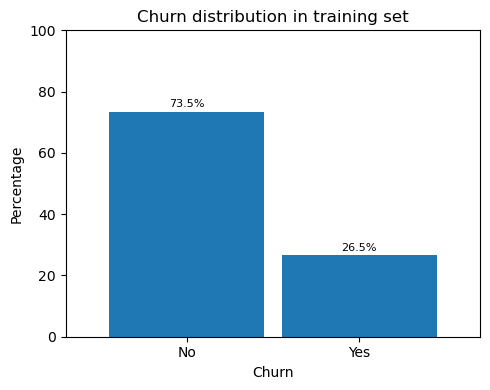

In [10]:
churn_distribution_ax = churn_overview['percentage'].plot(
    kind='bar',
    width=0.9,
    rot=0,
    figsize=(5, 4)
)
add_bar_labels(axes=churn_distribution_ax)
churn_distribution_ax.set_ylim(0, 100)
churn_distribution_ax.set_title('Churn distribution in training set')
churn_distribution_ax.set_xlabel('Churn')
churn_distribution_ax.set_ylabel('Percentage')
plt.tight_layout()
save_plot(
    path=EDA_OVERVIEW_DIR,
    file_name='churn_distribution_training_set',
)
plt.show()

## Summary

- The training dataset contains 5,634 rows.
- No duplicated rows or missing values were found.
- Column observations:
  - `customer_id` is a unique customer identifier. It will not be used as a model feature, but it will be retained to match model predictions with individual customers.
  - `senior_citizen` contains numerical values (`0` and `1`), but it represents a binary categorical feature and will be treated accordingly.
  - No columns that could cause target leakage were identified. All available features appear to be available before the churn prediction is made.
- Target column — `churn`:
  - The target distribution is moderately imbalanced, with a larger proportion of customers who did not churn.
  - The minority class represents customers who churned.

Key outputs from this notebook:
- Churn distribution plot saved to `reports/figures/eda/overview/churn_distribution_training_set.png`